In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import norm
import add_noise
import dfgen
from tabulate import tabulate
from tqdm import trange
from openpyxl import load_workbook
import csaps
import os

In [3]:
folder_name_1 = input('输入对比模型源文件夹1：')
folder_name_2 = input('输入对比模型源文件夹2：')

输入对比模型源文件夹1：model4
输入对比模型源文件夹2：model3


In [2]:
# 定义一些参数与路径
data_path = '../../data/net_data/'
param_path = '../../bat_mod/result/param.xlsx'
model_path_df = '../trained_model/' + folder_name_1
model_path_lstm = '../trained_model/' + folder_name_2
result_path = '../result/'
seq_len = 30
cap = 2000
initial_soc = 0.81

In [3]:
# 加载各个工况数据
data1 = pd.read_excel(data_path + 'SP2_25C_FUDS/fuds_80.xlsx').values
data2 = pd.read_excel(data_path + 'SP2_25C_DST/dst_80.xlsx').values
data3 = pd.read_excel(data_path + 'SP2_25C_BJDST/bjdst_80.xlsx').values
data4 = pd.read_excel(data_path + 'SP2_25C_US06/us06_80.xlsx').values
data5 = pd.read_excel(data_path + 'OTHER_DATA/incre.xlsx').values

In [4]:
# 加载用来写入结果的excel文件
book = load_workbook('../result/result.xlsx')
writer = pd.ExcelWriter('../result/result.xlsx', engine='openpyxl') 
writer.book = book

In [5]:
# 定义不同工况下的数据与路径
fuds  = {'data': data1, 'fig_path': '../result/fuds/', 'sheet_name': 'fuds'}
dst   = {'data': data2, 'fig_path': '../result/dst/', 'sheet_name': 'dst'}
bjdst = {'data': data3, 'fig_path': '../result/bjdst/', 'sheet_name': 'bjdst'}
us06  = {'data': data4, 'fig_path': '../result/us06/', 'sheet_name': 'us06'}

In [6]:
# 加载模型参数
param = pd.read_excel(param_path, header=None).values

# 用到的一些参数

## 电路模型参数

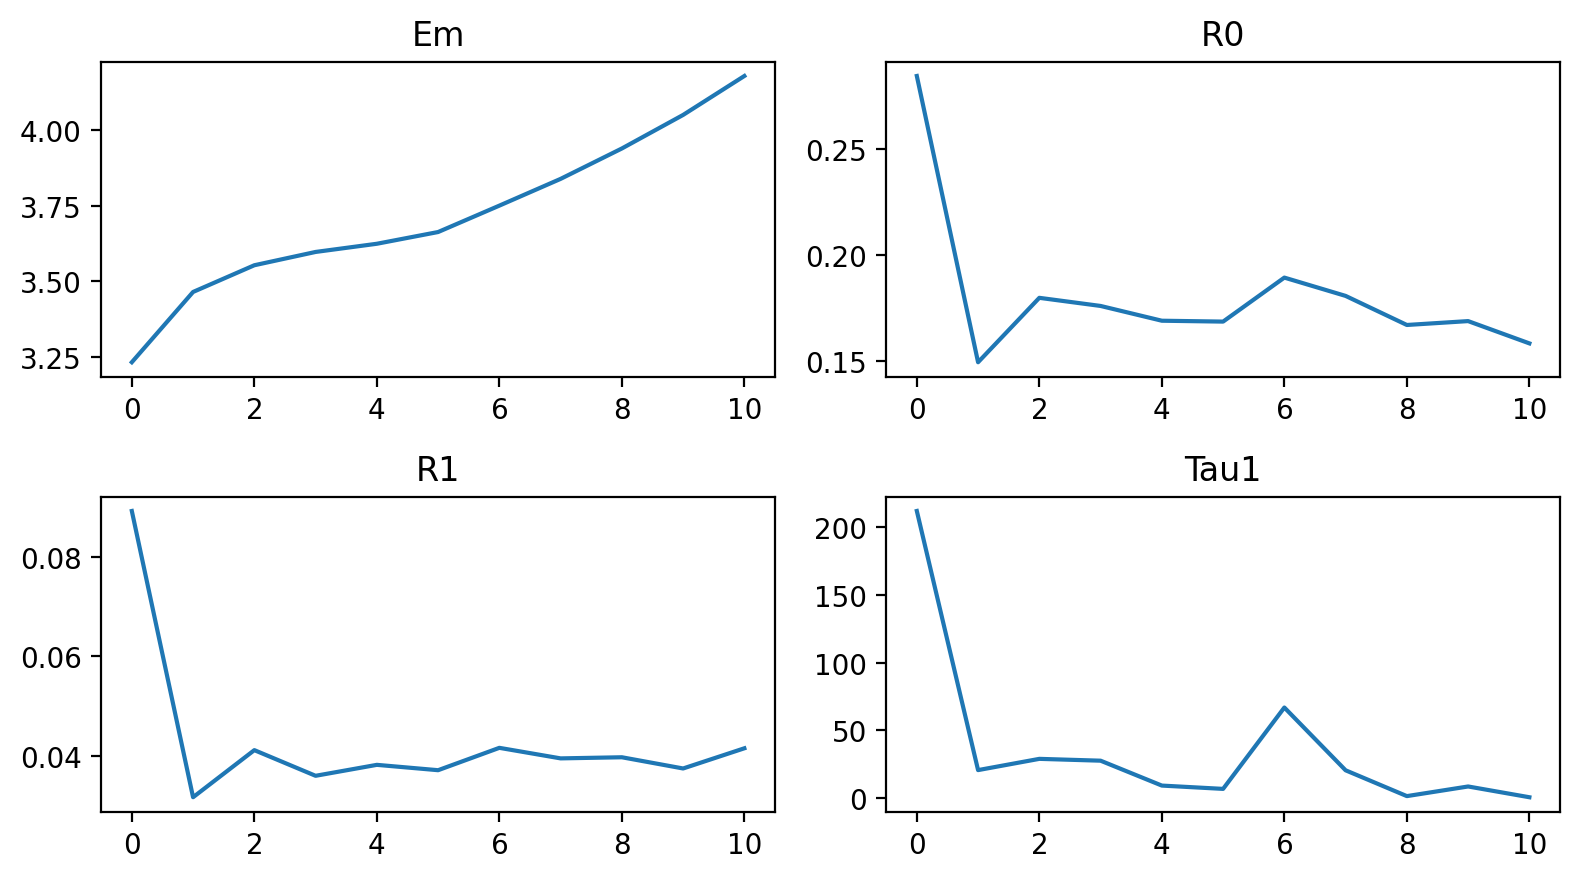

In [42]:
fig = plt.figure(figsize=(8,4.5), dpi=200)

# 第一个子图
plt.subplot(2, 2, 1)
plt.plot(param[:, 0])
plt.title('Em')

# 第二个子图
plt.subplot(2, 2, 2)
plt.plot(param[:, 1])
plt.title('R0')

# 第三个子图
plt.subplot(2, 2, 3)
plt.plot(param[:, 2])
plt.title('R1')

# 第四个子图
plt.subplot(2, 2, 4)
plt.plot(param[:, 3])
plt.title('Tau1')

# 调整子图之间的间距
plt.tight_layout()
plt.savefig(result_path + 'param.png')
plt.show()

## ocv曲线

In [8]:
key_point = []
for i in range(data5.shape[0] - 1):
    if (data5[i, 0] == 0 and data5[i+1, 0] != 0):
        key_point.append(i)

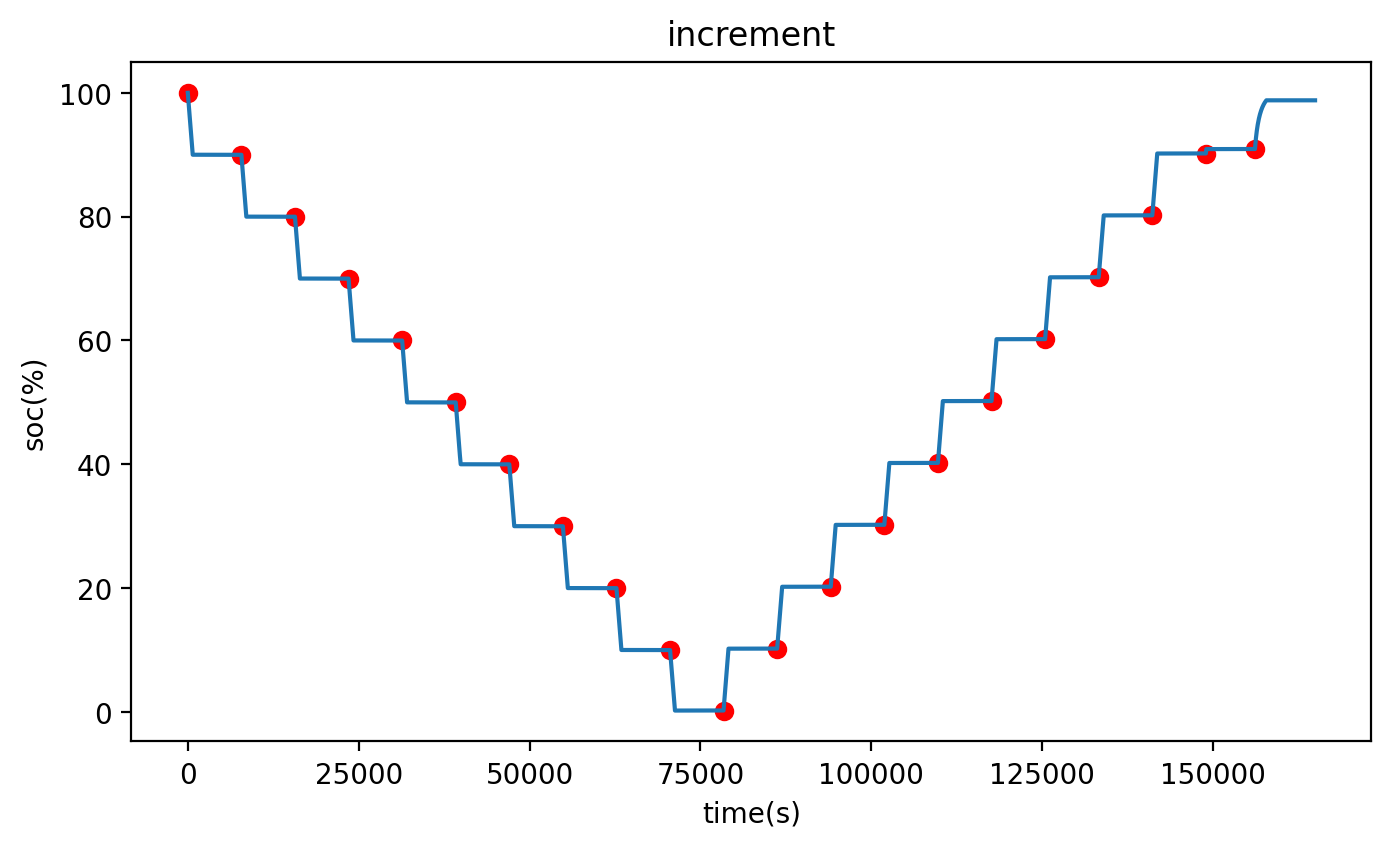

In [41]:
plt.figure(figsize=(8, 4.5), dpi=200)
plt.plot(data5[:, -1]*100)
plt.scatter(key_point, data5[key_point, -1]*100, c='r')
plt.xlabel('time(s)')
plt.ylabel('soc(%)')
plt.title('increment')

plt.savefig(result_path + 'key_point.png')
plt.show()

In [10]:
y_em = data5[np.array(key_point)[:11][::-1], 1]
f = csaps.CubicSmoothingSpline(np.linspace(0, 1, 11), y_em, smooth=0.9999973)

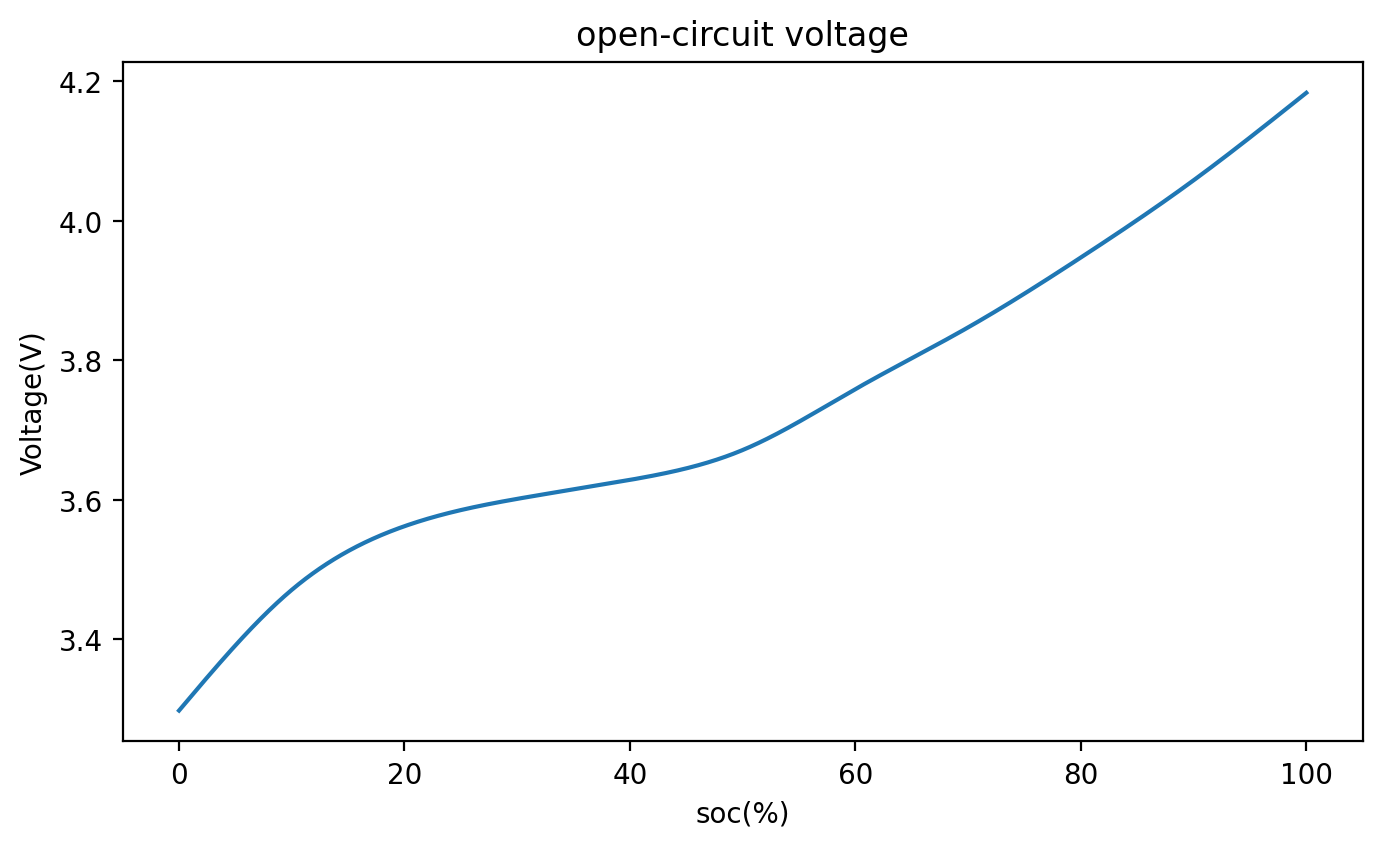

In [36]:
plt.figure(figsize=(8, 4.5), dpi=200)
x_plt = np.linspace(0, 1, 10001)
plt.plot(x_plt*100, f(x_plt))
plt.xlabel('soc(%)')
plt.ylabel('Voltage(V)')
plt.title('open-circuit voltage')

plt.savefig(result_path + 'ocv.png')
plt.show()

# 计算

In [12]:
# 设置工况
condition = bjdst

In [13]:
def data_gen(data):
    iu = np.round(data[:, :-1] * 1000)
    iu_noise = add_noise.add_noise_iu(iu)
    print(iu_noise.shape)
    data_len = int(data.shape[0] / seq_len)
    print(data_len)
    soc_real = []
    for i in range(data_len):
        soc = data[(i+1)*30-1, -1]
        soc_real.append(soc)
    soc_real = np.array(soc_real)
    return iu, iu_noise, data_len, soc_real

In [14]:
iu, iu_noise, data_len, soc_real = data_gen(condition['data'])

(11216, 2)
373


## 安时积分法

In [15]:
soc_ini = initial_soc
soc_ah = []
for i in range(data_len):
    iu = iu_noise[i*30:(i+1)*30, :]
    soc = soc_ini + np.sum(iu[:, 0]) / (cap*3600)
    soc_ah.append(soc)
    soc_ini = soc.copy()
soc_ah = np.array(soc_ah)

## lstm算法

In [16]:
model = torch.load(model_path_lstm + 'my_model.pth')
norm_dict = np.load(model_path_lstm + 'norm_dict.npy', allow_pickle=True).item()

In [17]:
soc_lstm = []
for i in trange(data_len):
    iu = iu_noise[i*30:(i+1)*30, :]
    x = iu.reshape(1, seq_len, -1)
    x_nm = norm.norm(x, norm_dict)
    x_ts = torch.from_numpy(x_nm).type(torch.float32)
    soc = model(x_ts).detach().numpy()
    soc_lstm.append(soc)
soc_lstm = np.array(soc_lstm)

100%|███████████████████████████████████████| 373/373 [00:04<00:00, 91.09it/s]


## 本算法

In [18]:
norm_dict = np.load(model_path_df + 'norm_dict.npy', allow_pickle=True).item()
model = torch.load(model_path_df + 'my_model.pth')

In [19]:
def smooth(soc_ini, soc, i):
    i_sum = np.sum(i)
    if (i_sum < 0 and soc > soc_ini) or (i_sum > 0 and soc < soc_ini):
        soc_new = soc_ini.copy()
    else:
        soc_new = soc.copy()
    return soc_new

In [20]:
soc_ini = np.array(initial_soc)
soc_df = []
for i in trange(data_len):
    iu = iu_noise[i*30:(i+1)*30, :]
    input_dict = {'iu': iu, 'soc_ini': soc_ini, 'cap': cap, 'param': param}
    x = dfgen.dfgen(input_dict).reshape(1, seq_len, -1)
    x_nm = norm.norm(x, norm_dict)
    x_ts = torch.from_numpy(x_nm).type(torch.float32)
    soc = model(x_ts).detach().numpy()
    soc_df.append(soc)
    soc_ini = soc.copy()
soc_df = np.array(soc_df)

100%|███████████████████████████████████████| 373/373 [00:04<00:00, 91.98it/s]


In [21]:
soc_ini = np.array(initial_soc)
soc_df = []
for i in trange(data_len):
    iu = iu_noise[i*30:(i+1)*30, :]
    input_dict = {'iu': iu, 'soc_ini': soc_ini, 'cap': cap, 'param': param}
    x = dfgen.dfgen(input_dict).reshape(1, seq_len, -1)
    x_nm = norm.norm(x, norm_dict)
    x_ts = torch.from_numpy(x_nm).type(torch.float32)
    soc = model(x_ts).detach().numpy()
    soc_df.append(soc)
    soc_ini = soc_ah[i]
soc_df = np.array(soc_df)

100%|███████████████████████████████████████| 373/373 [00:04<00:00, 91.97it/s]


# 对比

In [22]:
# 保留小数点后一位
soc_ah = np.around(soc_ah, decimals=3)
soc_df = np.around(soc_df, decimals=3)
soc_real = np.around(soc_real, decimals=3)

## 预测结果对比

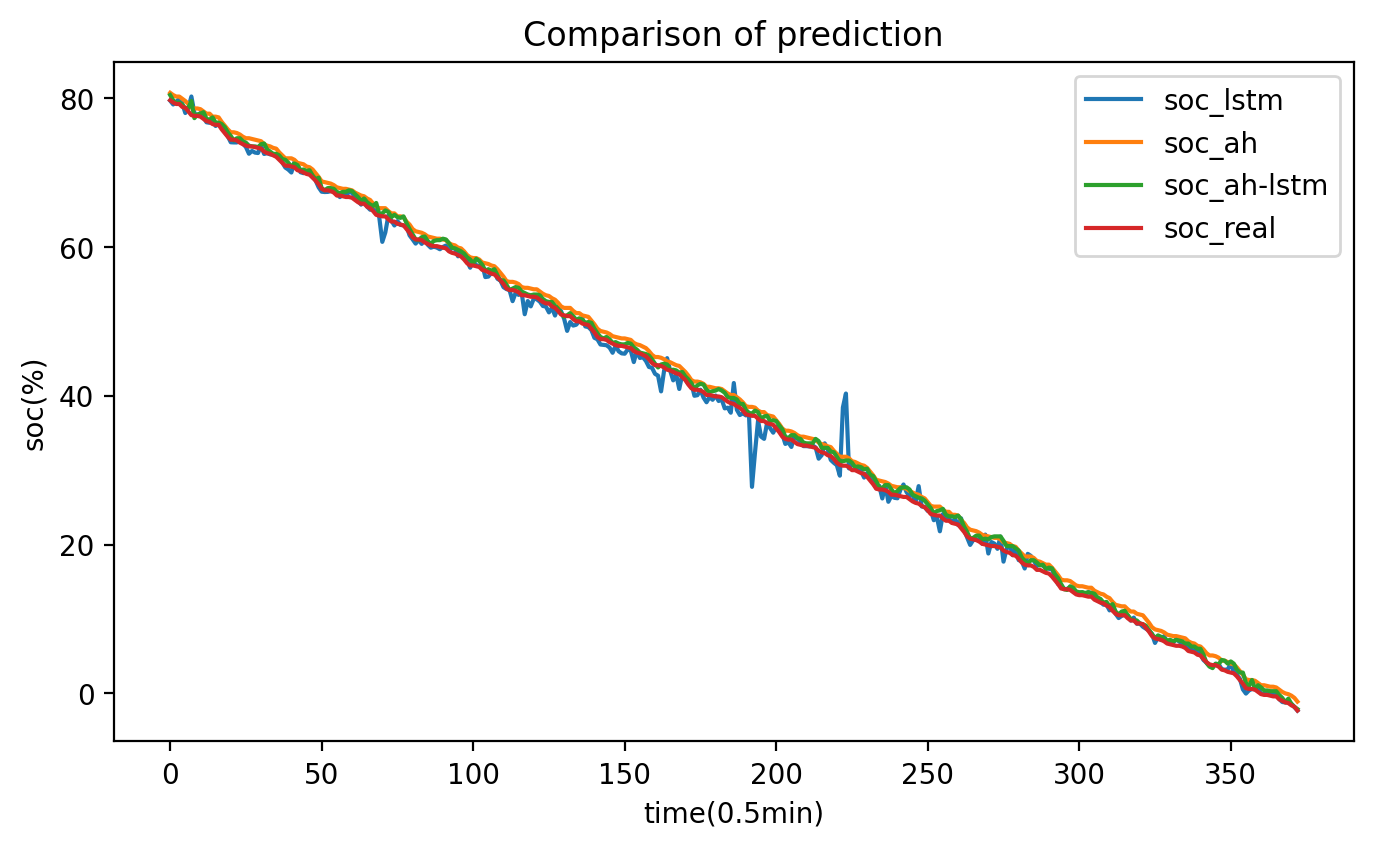

In [40]:
plt.figure(figsize=(8, 4.5), dpi=200)
plt.plot(soc_lstm * 100, label='soc_lstm')
plt.plot(soc_ah * 100, label='soc_ah')
plt.plot(soc_df * 100, label='soc_ah-lstm')
plt.plot(soc_real * 100, label='soc_real')
plt.ylabel('soc(%)')
plt.xlabel('time(0.5min)')
plt.title('Comparison of prediction')

plt.legend()
plt.savefig(condition['fig_path'] + 'result.png')
plt.show()

## 误差对比

In [24]:
erro_ah = np.abs(soc_ah - soc_real)
erro_lstm = np.abs(soc_lstm - soc_real)
erro_df = np.abs(soc_df - soc_real)

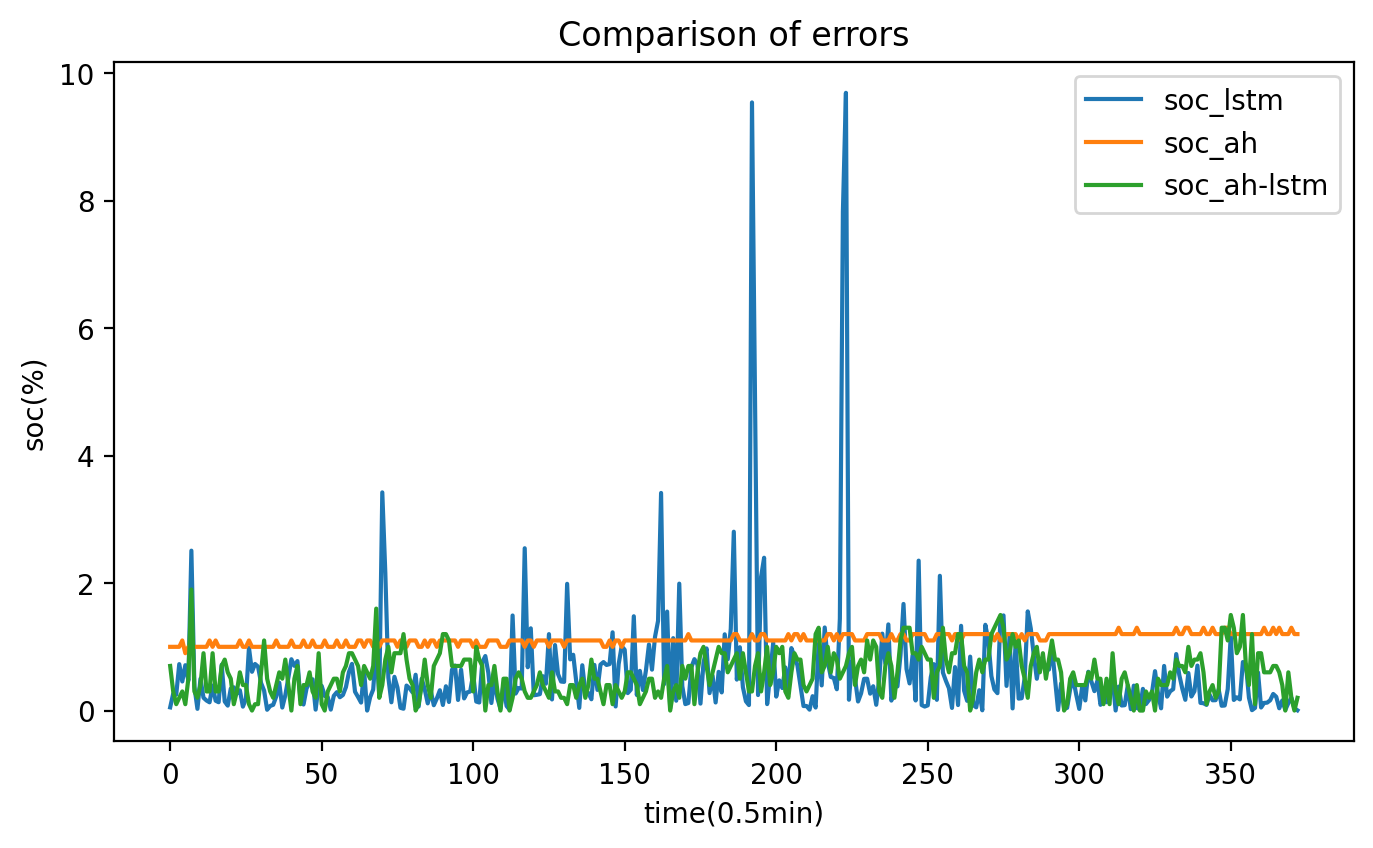

In [39]:
plt.figure(figsize=(8, 4.5), dpi=200)
plt.plot(erro_lstm * 100, label='soc_lstm')
plt.plot(erro_ah * 100, label='soc_ah')
plt.plot(erro_df * 100, label='soc_ah-lstm')

plt.ylabel('soc(%)')
plt.xlabel('time(0.5min)')
plt.title('Comparison of errors')

plt.legend()
plt.savefig(condition['fig_path'] + 'erro.png')
plt.show()

## 量化指标对比

In [26]:
def mae(erro):
    y = 100 * np.mean(erro)
    return y

In [27]:
def rmse(erro):
    y = 100 * np.sqrt(np.mean(np.power(erro, 2)))
    return y

In [28]:
def me(erro):
    y = 100 * np.max(erro)
    return y

In [29]:
mae_ah = mae(erro_ah)
rmse_ah = rmse(erro_ah)
me_ah = me(erro_ah)

mae_df = mae(erro_df)
rmse_df = rmse(erro_df)
me_df = me(erro_df)

mae_lstm = mae(erro_lstm)
rmse_lstm = rmse(erro_lstm)
me_lstm = me(erro_lstm)

In [30]:
dfdict = {"mae": [mae_ah, mae_lstm, mae_df], \
"rmse": [rmse_ah, rmse_lstm, rmse_df], \
"me": [me_ah, me_lstm, me_df]}

In [31]:
df = pd.DataFrame(dfdict)
print(df)

        mae      rmse        me
0  1.120643  1.123524  1.300000
1  0.581548  1.111451  9.693953
2  0.584182  0.677185  1.900000


In [32]:
df.to_excel(writer, condition['sheet_name'])
writer.save()

In [33]:
table_data = [
    ["ah", mae_ah, rmse_ah, me_ah],
    ["lstm", mae_lstm, rmse_lstm, me_lstm],
    ["ah_lstm", mae_df, rmse_df, me_df]
]
header = ["", "MAE", "RMSE", "ME"]

In [34]:
print(tabulate(table_data, tablefmt="fancy_grid", headers=header))

╒═════════╤══════════╤══════════╤═════════╕
│         │      MAE │     RMSE │      ME │
╞═════════╪══════════╪══════════╪═════════╡
│ ah      │ 1.12064  │ 1.12352  │ 1.3     │
├─────────┼──────────┼──────────┼─────────┤
│ lstm    │ 0.581548 │ 1.11145  │ 9.69395 │
├─────────┼──────────┼──────────┼─────────┤
│ ah_lstm │ 0.584182 │ 0.677185 │ 1.9     │
╘═════════╧══════════╧══════════╧═════════╛
